In [ ]:
import torch

In [ ]:
import kagglehub
import os
import random
from PIL import Image

In [ ]:
# Download dataset
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
# Build dataset paths
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Tomato___Bacterial_spot
256
256


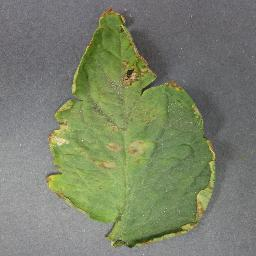

In [ ]:
classes=[name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path,name))]
class_name=random.choice(classes)
class_path=os.path.join(train_path,class_name)
img_name=random.choice(os.listdir(class_path))
img_path=os.path.join(class_path,img_name)
img=Image.open(img_path)
print(class_name)
print(img.width)
print(img.height)
img

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
s=torch.tensor(10)
s
s.ndim

0

In [ ]:
v=torch.tensor([10,10])
v
v.ndim

1

In [ ]:
m=torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
m

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [ ]:
t=torch.tensor([[[1,2,3],[4,5,6],[7,8,9]]])
t.ndim

3

In [ ]:
v=v.squeeze(dim=0)
v

tensor([10, 10])

In [ ]:
import torch

In [ ]:
weight,bias=0.7,0.3

In [ ]:
x=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=weight * x + bias
len(x),len(y)

(50, 50)

In [ ]:
train_split=int(0.8*len(x))
x_train,y_train=x[:train_split],y[:train_split]
x_test,y_test=x[train_split:],y[train_split:]

In [ ]:
class RegressionModel(nn.Module):
    def __init__(self):
      super().__init__()
      self.weight=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
      self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    def forward(self,x):
      return (self.weight * x) + self.bias

In [ ]:
torch.manual_seed(42)
model_first=RegressionModel()

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_first.parameters(),lr=0.01)

In [ ]:
def plot_predictions(x_train,y_train,x_test,y_test,y_preds=None):
  plt.scatter(x_train,y_train,c="b")
  plt.scatter(x_test,y_test,c="g")
  if y_preds is not None:
    plt.scatter(x_test,y_preds,c="r")

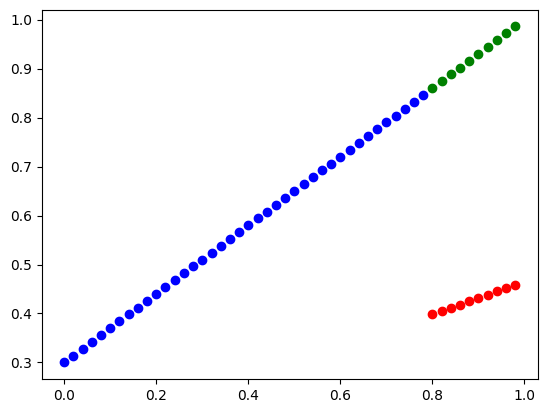

In [ ]:
with torch.inference_mode():
  y_preds=model_first(x_test)
plot_predictions(x_train,y_train,x_test,y_test,y_preds)

In [ ]:
torch.manual_seed(42)
epochs=200
for epoch in range(epochs):
  model_first.train()
  y_preds=model_first(x_train)
  loss=loss_fn(y_preds,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step
  model_first.eval()
  with torch.inference_mode():
    test_preds=model_first(x_test)
    test_loss=loss_fn(test_preds,y_test)

  if epoch%10==0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 10 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 20 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 30 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 40 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 50 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 60 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 70 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 80 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 90 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 100 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 110 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 120 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 130 | Loss: 0.31288138031959534 | Test Loss: 0.4945361614227295
Epoch: 140 | Loss

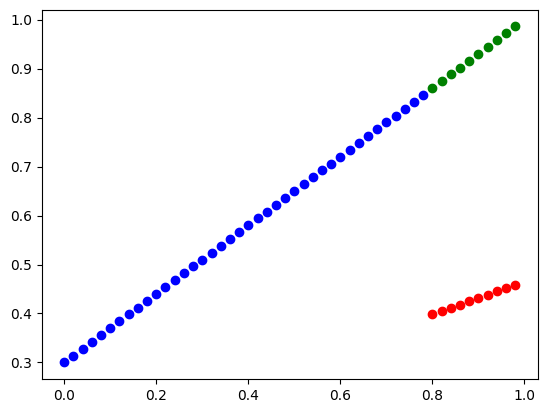

In [ ]:
with torch.inference_mode():
  y_preds=model_first(x_test)
plot_predictions(x_train,y_train,x_test,y_test,y_preds)

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
  class RegressionModel(nn.Module):
    def __init__(self):
      super().__init__()
      self.linear=nn.Linear(1,1)
    def forward(self,x):
      return self.linear(x)

  model=RegressionModel()

  x=torch.tensor([[5.0]])
  y_pred=model(x)
  print("Prediction:", y_pred.item())

Prediction: 4.652700424194336


In [ ]:
len(classes)

38

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [ ]:
data_transformer=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
train_dataset=datasets.ImageFolder(root=train_path,transform=None)

In [ ]:
valid_dataset=datasets.ImageFolder(root=val_path,transform=data_transformer)

In [ ]:
len(train_dataset),len(valid_dataset)

(70295, 17572)

In [ ]:
transformed_img=data_transformer(img)
print(transformed_img)

tensor([[[ 0.4510,  0.4902,  0.4745,  ...,  0.2314,  0.3961,  0.1137],
         [ 0.4196,  0.4431,  0.4196,  ...,  0.3176,  0.3176,  0.3569],
         [ 0.4275,  0.4353,  0.4039,  ...,  0.3961,  0.2627,  0.4431],
         ...,
         [ 0.2784,  0.3647,  0.3255,  ...,  0.1529,  0.1686,  0.0353],
         [ 0.3255,  0.3725,  0.3020,  ...,  0.1451,  0.1843,  0.1137],
         [ 0.3725,  0.3804,  0.2706,  ...,  0.0745,  0.1686,  0.2000]],

        [[ 0.2157,  0.2549,  0.2392,  ..., -0.0118,  0.1529, -0.1294],
         [ 0.1843,  0.2078,  0.1843,  ...,  0.0745,  0.0745,  0.1137],
         [ 0.1922,  0.2000,  0.1686,  ...,  0.1529,  0.0196,  0.2000],
         ...,
         [ 0.0039,  0.0902,  0.0510,  ..., -0.0902, -0.0745, -0.2078],
         [ 0.0510,  0.0980,  0.0275,  ..., -0.0980, -0.0588, -0.1294],
         [ 0.0980,  0.1059, -0.0039,  ..., -0.1686, -0.0745, -0.0431]],

        [[ 0.2314,  0.2706,  0.2549,  ..., -0.0275,  0.1373, -0.1451],
         [ 0.2000,  0.2235,  0.2000,  ...,  0

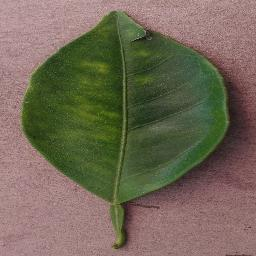

In [ ]:
img

In [ ]:
train_loader=DataLoader(dataset=train_dataset,batch_size=32,shuffle=True,num_workers=2)
valid_loader=DataLoader(dataset=valid_dataset,batch_size=32,shuffle=False,num_workers=2)

In [ ]:
len(train_loader),len(valid_loader)

(2197, 550)

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
dummy_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset=datasets.ImageFolder(root=train_path,transform=dummy_transform)
valid_dataset=datasets.ImageFolder(root=val_path,transform=dummy_transform)

In [ ]:
def compute_mean_std(dataset,batch_size=16,num_workers=2):
  loader=DataLoader(dataset,batch_size=batch_size,shuffle=False,num_workers=2)
  channels_sum=torch.zeros(3,device=device)
  channels_squared_sum=torch.zeros(3,device=device)
  pixel_count=0

  for x, _ in loader:
    x=x.to(device)
    b,c,h,w,=x.shape
    pixel_count+=b*h*w
    channels_sum+=torch.sum(x,dim=[0,2,3])
    channels_squared_sum+=torch.sum(x**2,dim=[0,2,3])
    batch_sum=torch.sum(x,dim=[0,2,3])

    mean=channels_sum/pixel_count
    std=torch.sqrt(channels_squared_sum/pixel_count-mean**2)
    return mean,std


  def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    mean = 0.
    std = 0.
    total_images = 0

  for images, _ in tqdm(loader):
      batch_samples = images.size(0)  # batch size (N)
      images = images.view(batch_samples, images.size(1), -1)  # [N, C, H*W]
      mean += images.mean(2).sum(0)
      std  += images.std(2).sum(0)
      total_images += batch_samples

      mean /= total_images
      std /= total_images
      return mean, std


In [ ]:
  mean,std=compute_mean_std(train_dataset)
  mean=mean.tolist()
  std=std.tolist()

In [ ]:
mean,std

([0.361847847700119, 0.4157635569572449, 0.3899894952774048],
 [0.18708214163780212, 0.17410749197006226, 0.21723629534244537])

In [ ]:
mean = [0.47596338391304016, 0.5003822445869446, 0.42664194107055664]
std = [0.21028108894824982, 0.18884526193141937, 0.22626696527004242]

In [ ]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Normalize(mean=[],std=[])
])

In [ ]:
train_loader=DataLoader(dataset=train_dataset,batch_size=32,shuffle=True,num_workers=2)
test_loader=DataLoader(dataset=valid_dataset,batch_size=32,shuffle=False,num_workers=2)

In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self,in_features,out_features,hidden_units
               ):
    super().__init__()
    self.layer=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_features,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=out_features)
    )
  def forward(self,x):
    return self.layer(x)


In [ ]:
simpleCNN=SimpleCNN(3*224*224,38,256)

In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(simpleCNN.parameters(),lr=0.1)

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Convolutional layers to extract features
        self.conv_layers = nn.Sequential(
            # First convolutional block
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Second convolutional block
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Third convolutional block
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 32 * 32, out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512, out_features=num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=10)
print(model)


SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Model
# =========================
class PlantCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(0.5)

        # Make feature size input-agnostic
        # Squeeze spatial size to a fixed 4x4 before the linear layers
        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1  = nn.Linear(128 * 4 * 4, 256)
        self.fc2  = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # -> 1/2 spatial
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # -> 1/4 spatial
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # -> 1/8 spatial

        # Make spatial dimension fixed regardless of input size
        x = self.gap(x)                                  # -> (B, 128, 4, 4)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)                                  # logits
        return x


# =========================
# Training / Evaluation
# =========================
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss, running_acc, count = 0.0, 0.0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            # Mixed precision
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_acc  += accuracy_from_logits(outputs, labels) * batch_size
        count        += batch_size

    return running_loss / count, running_acc / count

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_acc, count = 0.0, 0.0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_acc  += accuracy_from_logits(outputs, labels) * batch_size
        count        += batch_size

    return running_loss / count, running_acc / count


# =========================
# Main loop (plug your loaders here)
# =========================
def run_training(train_loader, val_loader, num_classes, epochs=15, lr=1e-3, save_path="plantcnn_best.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PlantCNN(num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Optional: scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

    # Mixed precision if CUDA available
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_loss, val_acc     = evaluate(model, val_loader, criterion, device)

        # Step scheduler on validation accuracy
        scheduler.step(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%")

        # Save best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "val_acc": best_val_acc,
            }, save_path)
            print(f"Saved best model to {save_path} (val acc: {best_val_acc*100:.2f}%)")

    print(f"Best Val Acc: {best_val_acc*100:.2f}%")
    return model

